In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create the time grid.
T = 100.0  # length of the time interval
dt = 0.02  # time-step size
num_steps = int(T / dt)  # number of time steps
t = np.linspace(0.0, T, num=num_steps + 1)  # time grid

In [3]:
# Set the model parameters and initial conditions.
z_0 = 100.0  # initial depth below the energy reference
b_0 = 10.0   # initial downward velocity from a gust or downdraft
z_t = 100.0  # equilibrium depth for trimmed flight
g = 9.81     # acceleration due to gravity

# Set the initial value of the numerical solution.
u = np.array([z_0, b_0])

# Create an array to store the depth coordinate at each grid point.
z = np.zeros(num_steps + 1)
z[0] = z_0

In [4]:
# Temporal integration using Euler's method.
for n in range(num_steps):
    z_n, b_n = u
    du_dt = np.array([b_n, g * (1.0 - z_n / z_t)])
    u = u + dt * du_dt
    z[n + 1] = u[0]

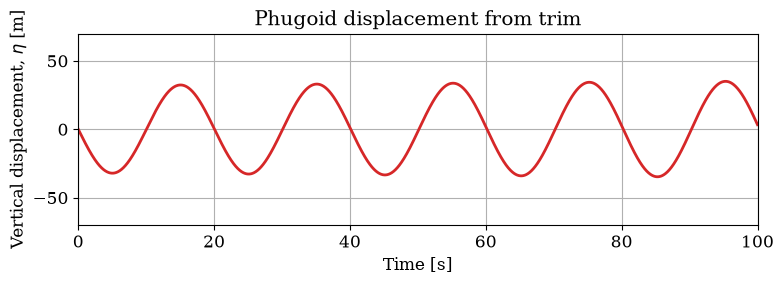

In [5]:
# Set the font family and size to use for Matplotlib figures.
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

# Convert depth to vertical displacement, positive upward.
eta = z_t - z

# Plot the vertical displacement from trim.
fig, ax = plt.subplots(figsize=(8, 3))
ax.set_title('Phugoid displacement from trim')
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'Vertical displacement, $\eta$ [m]')
ax.set_xlim(t[0], t[-1])
ax.set_ylim(-70.0, 70.0)
ax.grid()
ax.plot(t, eta, color='tab:red', linestyle='-', linewidth=2)
fig.tight_layout()

In [6]:
omega = np.sqrt(g / z_t)
z_exact = (
    b_0 / omega * np.sin(omega * t)
    + (z_0 - z_t) * np.cos(omega * t)
    + z_t
)
eta_exact = z_t - z_exact

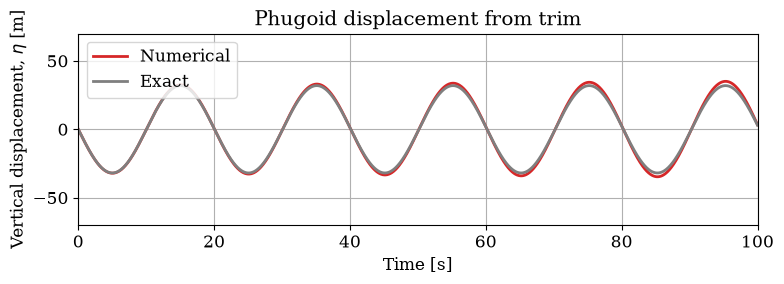

In [7]:
# Plot the numerical and exact vertical displacements.
fig, ax = plt.subplots(figsize=(8, 3))
ax.set_title('Phugoid displacement from trim')
ax.set_xlabel('Time [s]')
ax.set_ylabel(r'Vertical displacement, $\eta$ [m]')
ax.set_xlim(t[0], t[-1])
ax.set_ylim(-70.0, 70.0)
ax.grid()
ax.plot(
    t, eta, label='Numerical',
    color='tab:red', linestyle='-', linewidth=2,
)
ax.plot(
    t, eta_exact, label='Exact',
    color='tab:grey', linestyle='-', linewidth=2,
)
ax.legend()
fig.tight_layout()

In [8]:
# Set the list of time-step sizes.
dt_values = [0.1, 0.05, 0.01, 0.005, 0.001, 0.0001]

# Create an empty list for the depth-coordinate solution on each grid.
z_solutions = []

for dt_trial in dt_values:
    num_steps_trial = int(T / dt_trial)
    t_trial = np.linspace(0.0, T, num=num_steps_trial + 1)
    # Set the initial conditions.
    u_trial = np.array([z_0, b_0])
    z_trial = np.zeros(num_steps_trial + 1)
    z_trial[0] = z_0
    # Temporal integration using Euler's method.
    for n in range(num_steps_trial):
        z_n, b_n = u_trial
        du_dt = np.array([b_n, g * (1.0 - z_n / z_t)])
        u_trial = u_trial + dt_trial * du_dt
        z_trial[n + 1] = u_trial[0]
    z_solutions.append(z_trial)

In [9]:
def l1_error(z_numerical, z_exact, dt):
    '''Return the discrete L1 error in the numerical depth coordinate.
    
    Parameters
    ----------
    z_numerical : np.ndarray
        The numerical depth coordinate as an array of floats.
    z_exact : np.ndarray
        The exact depth coordinate as an array of floats.
    dt : float
        The time-step size.
        
    Returns
    -------
    error : float
        Discrete L1 error with respect to the exact solution.
    '''
    return dt * np.sum(np.abs(z_numerical - z_exact))

In [10]:
a = np.array([1, 2, 3])
b = np.array([4, 4, 4])

b - a

array([3, 2, 1])

In [ ]:
# Create an empty list to store the errors on each time grid.
error_values = []

for z_trial, dt_trial in zip(z_solutions, dt_values):
    num_steps_trial = int(T / dt_trial)
    t_trial = np.linspace(0.0, T, num=num_steps_trial + 1)
    # Compute the exact depth-coordinate solution.
    z_exact_trial = (
        b_0 / omega * np.sin(omega * t_trial)
        + (z_0 - z_t) * np.cos(omega * t_trial)
        + z_t
    )
    # Calculate the L1-norm of the error for the present time grid.
    error_values.append(l1_error(z_trial, z_exact_trial, dt_trial))

In [ ]:
# Construct a first-order reference line through the finest-grid error.
dt_array = np.array(dt_values)
first_order_reference = error_values[-1] * dt_array / dt_array[-1]

# Plot the error versus the time-step size.
fig, ax = plt.subplots(figsize=(5.0, 5.0))
ax.set_title(r'$L_1$ error vs. time-step size')
ax.set_xlabel(r'$\Delta t$')
ax.set_ylabel('Error')
ax.grid()
ax.loglog(
    dt_array, error_values, label='Forward Euler error',
    color='tab:red', linestyle='--', marker='o',
)
ax.loglog(
    dt_array, first_order_reference, label=r'Expected $O(\Delta t)$',
    color='tab:blue', linestyle='-',
)
ax.set_aspect('equal', adjustable='box')
ax.legend()
fig.tight_layout()

In [ ]:
# Preserve reference results from the direct implementation.
z_direct = z.copy()
error_values_direct = np.array(error_values)

# Define an independent, non-equilibrium test case.
u_test = np.array([120.0, -3.0])
g_test = 10.0
z_t_test = 80.0
dt_test = 0.1

# Expected values calculated directly from the equations.
rhs_expected = np.array([-3.0, -5.0])
u_next_expected = np.array([119.7, -3.5])